# Exploratory Data Analysis (EDA)
## Dataset: credit_card_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `credit_card_balance` dataset from the Home Credit risk modeling case. This table contains monthly balance snapshots of previous credit cards held by applicants at Home Credit, providing behavioral signals on credit card usage and payment patterns for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `credit_card_balance` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationships between features)
- Aggregation strategy (credit_card_balance to SK_ID_CURR)
- Bivariate analysis of aggregated features vs TARGET
- Initial business-driven interpretation of credit card usage behavior

---

## 🧠 Key Questions
- What is the credit card usage profile of applicants at Home Credit?
- How do credit utilization and payment patterns relate to default behavior?
- What aggregated signals from credit_card_balance are most predictive of default?
- Are there patterns in overdue payments that differentiate defaulters?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- Aggregated credit card balance features ready for merging into the main modeling table
- Business insights on credit card usage and payment behavior
- Input for feature selection and credit scoring models

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importing Dataset

In [3]:
# Dataset credit_card_balance
credit_card_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\credit_card_balance.csv'
df_cc = pd.read_csv(credit_card_path)

# Dataset application_train (for bivariate aggregated features vs TARGET)
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# 1. About Dataset

The dataset consists of **3,840,312 observations** and **23 features**, representing monthly balance snapshots of previous credit cards held by applicants at Home Credit. Each row corresponds to one month of history for a given credit card, linked to an applicant via `SK_ID_CURR` and to a specific previous credit card via `SK_ID_PREV`.

The features can be grouped into several categories:
- **Key identifiers**: `SK_ID_PREV` (link to previous_application) and `SK_ID_CURR` (link to main table)
- **Balance features**: `AMT_BALANCE`, `AMT_RECEIVABLE_PRINCIPAL`, `AMT_RECIVABLE`, `AMT_TOTAL_RECEIVABLE`, `AMT_CREDIT_LIMIT_ACTUAL`
- **Drawing features**: `AMT_DRAWINGS_ATM_CURRENT`, `AMT_DRAWINGS_CURRENT`, `AMT_DRAWINGS_OTHER_CURRENT`, `AMT_DRAWINGS_POS_CURRENT` and their count variants
- **Payment features**: `AMT_INST_MIN_REGULARITY`, `AMT_PAYMENT_CURRENT`, `AMT_PAYMENT_TOTAL_CURRENT`
- **Temporal features**: `MONTHS_BALANCE`, `CNT_INSTALMENT_MATURE_CUM`
- **DPD features**: `SK_DPD`, `SK_DPD_DEF`
- **Categorical feature**: `NAME_CONTRACT_STATUS`

In [4]:
df_cc.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE_CUM   floa

# 2. Contract Status Distribution

The contract status distribution shows the monthly status of previous credit cards held by applicants at Home Credit. Understanding the proportion of active, completed, and delinquent contracts provides an initial signal of the credit card usage and payment behavior profile across applicants.

- Total Active: 3,698,436 (~96.31%)
- Total Completed: 128,918 (~3.36%)
- Total Signed: 11,058 (~0.29%)
- Total Demand: 1,365 (~0.04%)
- Total Sent proposal: 513 (~0.01%)
- Total Refused: 17 (~0.00%)
- Total Approved: 5 (~0.00%)

The vast majority of monthly records are **Active (~96.31%)**, significantly higher than the 91.50% seen in `POS_CASH_balance`, reflecting that credit cards tend to remain open longer than POS/cash loans. **Completed (~3.36%)** represents fully closed credit cards. `Demand`, `Sent proposal`, `Refused`, and `Approved` are collectively negligible at less than 0.05% but `Demand` in particular may carry meaningful risk signal during aggregation.

In [5]:
# Contract status value counts
print(df_cc['NAME_CONTRACT_STATUS'].value_counts())
print(f"\nContract Status Distribution (%):")
print((df_cc['NAME_CONTRACT_STATUS'].value_counts() / len(df_cc) * 100).round(2))

NAME_CONTRACT_STATUS
Active           3698436
Completed         128918
Signed             11058
Demand              1365
Sent proposal        513
Refused               17
Approved               5
Name: count, dtype: int64

Contract Status Distribution (%):
NAME_CONTRACT_STATUS
Active           96.31
Completed         3.36
Signed            0.29
Demand            0.04
Sent proposal     0.01
Refused           0.00
Approved          0.00
Name: count, dtype: float64


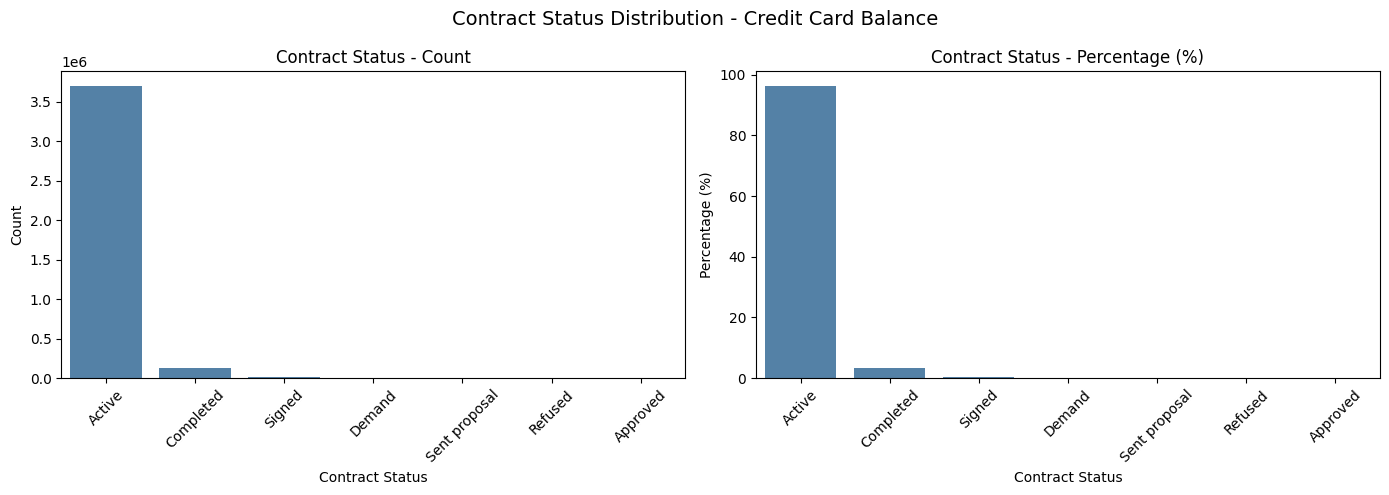

In [6]:
# Bar plot - contract status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
contract_status_counts = df_cc['NAME_CONTRACT_STATUS'].value_counts()
sns.barplot(x=contract_status_counts.index, y=contract_status_counts.values, ax=axes[0], color='steelblue')
axes[0].set_title('Contract Status - Count')
axes[0].set_xlabel('Contract Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Percentage plot
contract_status_pct = df_cc['NAME_CONTRACT_STATUS'].value_counts(normalize=True) * 100
sns.barplot(x=contract_status_pct.index, y=contract_status_pct.values, ax=axes[1], color='steelblue')
axes[1].set_title('Contract Status - Percentage (%)')
axes[1].set_xlabel('Contract Status')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Contract Status Distribution - Credit Card Balance', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Evaluating** the likely cause of missingness based on domain context
- **Defining** a handling strategy for each missing feature

The results of this analysis serve as recommendations for the data handling stage, including imputing values and deciding whether missingness itself carries meaningful signal.

In [7]:
# Missing value count and percentage
missing_cc = pd.DataFrame({
    'Missing Count': df_cc.isnull().sum(),
    'Missing (%)': (df_cc.isnull().sum() / len(df_cc) * 100).round(2)
})
missing_cc = missing_cc[missing_cc['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

if missing_cc.empty:
    print("No missing values found in credit_card_balance.")
else:
    print(missing_cc)

                            Missing Count  Missing (%)
AMT_PAYMENT_CURRENT                767988        20.00
AMT_DRAWINGS_ATM_CURRENT           749816        19.52
AMT_DRAWINGS_OTHER_CURRENT         749816        19.52
AMT_DRAWINGS_POS_CURRENT           749816        19.52
CNT_DRAWINGS_ATM_CURRENT           749816        19.52
CNT_DRAWINGS_POS_CURRENT           749816        19.52
CNT_DRAWINGS_OTHER_CURRENT         749816        19.52
AMT_INST_MIN_REGULARITY            305236         7.95
CNT_INSTALMENT_MATURE_CUM          305236         7.95


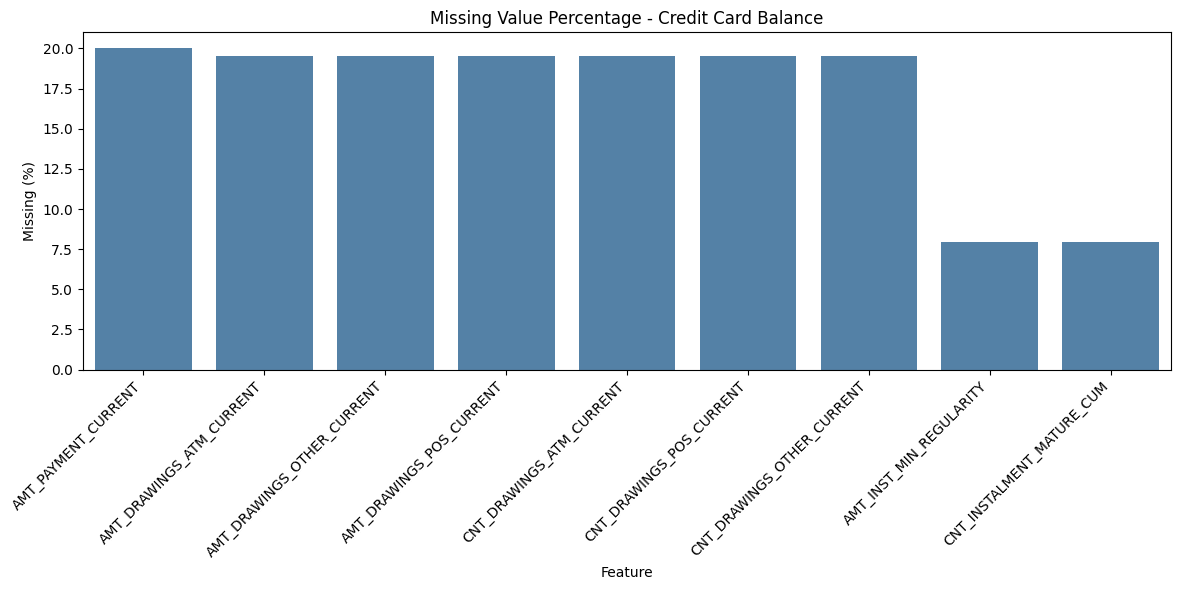

In [8]:
# Visualization of missing values
if not missing_cc.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_cc.index, y=missing_cc['Missing (%)'], color='steelblue')
    plt.title('Missing Value Percentage - Credit Card Balance')
    plt.ylabel('Missing (%)')
    plt.xlabel('Feature')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Key Findings & Handling Strategy

The `credit_card_balance` dataset contains **9 features with missing values**, all of which are numerical.

Key observations:
- `AMT_PAYMENT_CURRENT` (20.00%) is missing slightly more than the drawing features, suggesting some months have no payment recorded independent of drawing activity.
- `AMT_DRAWINGS_ATM_CURRENT`, `AMT_DRAWINGS_OTHER_CURRENT`, `AMT_DRAWINGS_POS_CURRENT` and their count variants (19.52%) are all missing together for the same rows, likely reflecting months where no drawing activity was recorded or the data was not captured for older credit card records.
- `AMT_INST_MIN_REGULARITY` and `CNT_INSTALMENT_MATURE_CUM` (7.95%) are missing together, likely reflecting credit cards without a defined installment schedule.

**Handling Strategy:**
- `AMT_DRAWINGS_ATM_CURRENT`, `AMT_DRAWINGS_OTHER_CURRENT`, `AMT_DRAWINGS_POS_CURRENT` and count variants: impute with **0**, missing likely indicates no drawing activity for that month
- `AMT_PAYMENT_CURRENT`: impute with **0**, missing likely indicates no payment made that month
- `AMT_INST_MIN_REGULARITY`, `CNT_INSTALMENT_MATURE_CUM`: impute with **median** per `NAME_CONTRACT_STATUS` group, as installment structure varies by contract type

# 4. Numerical Features Analysis

Numerical features in `credit_card_balance` are analyzed to understand their distributions, central tendencies, and relationships. This section covers both univariate and bivariate analysis before aggregation.

The approach includes:
- **Describing** each feature through summary statistics
- **Visualizing** distributions to detect skewness and anomalies
- **Detecting** outliers using boxplots
- **Examining** pairwise correlations between numerical features

In [9]:
# Numerical features in credit_card_balance (exclude identifiers)
num_cols_cc = df_cc.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_cc = [col for col in num_cols_cc if col not in ['SK_ID_PREV', 'SK_ID_CURR']]

## 4.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand its distribution, central tendency, and spread. This serves as the foundation before exploring relationships between features.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

### 4.1.1 Statistical Descriptive

In [10]:
# Statistical description
df_cc[num_cols_cc].describe().T

,count,mean,std,min,25%,50%,75%,max
MONTHS_BALANCE,3840312.0,-34.521921,26.667751,-96.000,-55.00,-28.0,-11.00000,-1.000
AMT_BALANCE,3840312.0,58300.155262,106307.031024,-420250.185,0.00,0.0,89046.68625,1505902.185
AMT_CREDIT_LIMIT_ACTUAL,3840312.0,153807.957400,165145.699525,0.000,45000.00,112500.0,180000.00000,1350000.000
AMT_DRAWINGS_ATM_CURRENT,3090496.0,5961.324822,28225.688578,-6827.310,0.00,0.0,0.00000,2115000.000
AMT_DRAWINGS_CURRENT,3840312.0,7433.388179,33846.077333,-6211.620,0.00,0.0,0.00000,2287098.315
AMT_DRAWINGS_OTHER_CURRENT,3090496.0,288.169582,8201.989345,0.000,0.00,0.0,0.00000,1529847.000
AMT_DRAWINGS_POS_CURRENT,3090496.0,2968.804848,20796.887047,0.000,0.00,0.0,0.00000,2239274.160
AMT_INST_MIN_REGULARITY,3535076.0,3540.204129,5600.154122,0.000,0.00,0.0,6633.91125,202882.005
AMT_PAYMENT_CURRENT,3072324.0,10280.537702,36078.084953,0.000,152.37,2702.7,9000.00000,4289207.445
AMT_PAYMENT_TOTAL_CURRENT,3840312.0,7588.856739,32005.987768,0.000,0.00,0.0,6750.00000,4278315.690


##### Key Findings

**MONTHS_BALANCE (Negative Values by Design)**
`MONTHS_BALANCE` ranges from -96 to -1, negative by design representing months relative to application date. Median of -28 indicates the typical observation is approximately 28 months before application. Consistent with POS_CASH_balance pattern.

**Anomalies Detected**
- `AMT_BALANCE`, `AMT_RECEIVABLE_PRINCIPAL`, `AMT_RECIVABLE`, `AMT_TOTAL_RECEIVABLE` all have negative minimum values (down to -423,305), which are not meaningful for balance features and require investigation.
- `AMT_DRAWINGS_ATM_CURRENT` min = **-6,827**, negative drawing amount is suspicious and requires handling.
- `AMT_DRAWINGS_CURRENT` min = **-6,211**, same issue as above.
- `SK_DPD` max = **3,260** and `SK_DPD_DEF` max = **3,260**, extreme outliers consistent with POS_CASH_balance findings.

**High Multicollinearity Expected**
`AMT_BALANCE`, `AMT_RECEIVABLE_PRINCIPAL`, `AMT_RECIVABLE`, and `AMT_TOTAL_RECEIVABLE` show nearly identical mean, std, min, and max values, suggesting very high redundancy among these balance features. Consider retaining only one during feature selection.

**Skewed Distributions**
- All amount features have median = 0 with large means, confirming heavy right-skew and sparse non-zero activity per month.
- `AMT_CREDIT_LIMIT_ACTUAL` mean 153,808 vs median 112,500, moderately right-skewed.
- `AMT_PAYMENT_CURRENT` and `AMT_PAYMENT_TOTAL_CURRENT` have median = 0 with extreme max values up to 4.3M, heavily right-skewed.

**Near-Zero Activity Features**
- All drawing count features (`CNT_DRAWINGS_*`) have median = 0, confirming drawing events are sparse across monthly records.
- `CNT_DRAWINGS_OTHER_CURRENT` mean = 0.005, near-constant and likely low signal.

**Features for Further Analysis**
- `AMT_BALANCE`, `AMT_CREDIT_LIMIT_ACTUAL` to examine credit utilization ratio
- `SK_DPD`, `SK_DPD_DEF` to confirm outlier severity
- `AMT_PAYMENT_CURRENT` vs `AMT_INST_MIN_REGULARITY` to examine payment behavior relative to minimum required

---

### 4.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature - whether it is normally distributed, right-skewed, or contains anomalies. Features with high skewness may require log transformation during preprocessing.

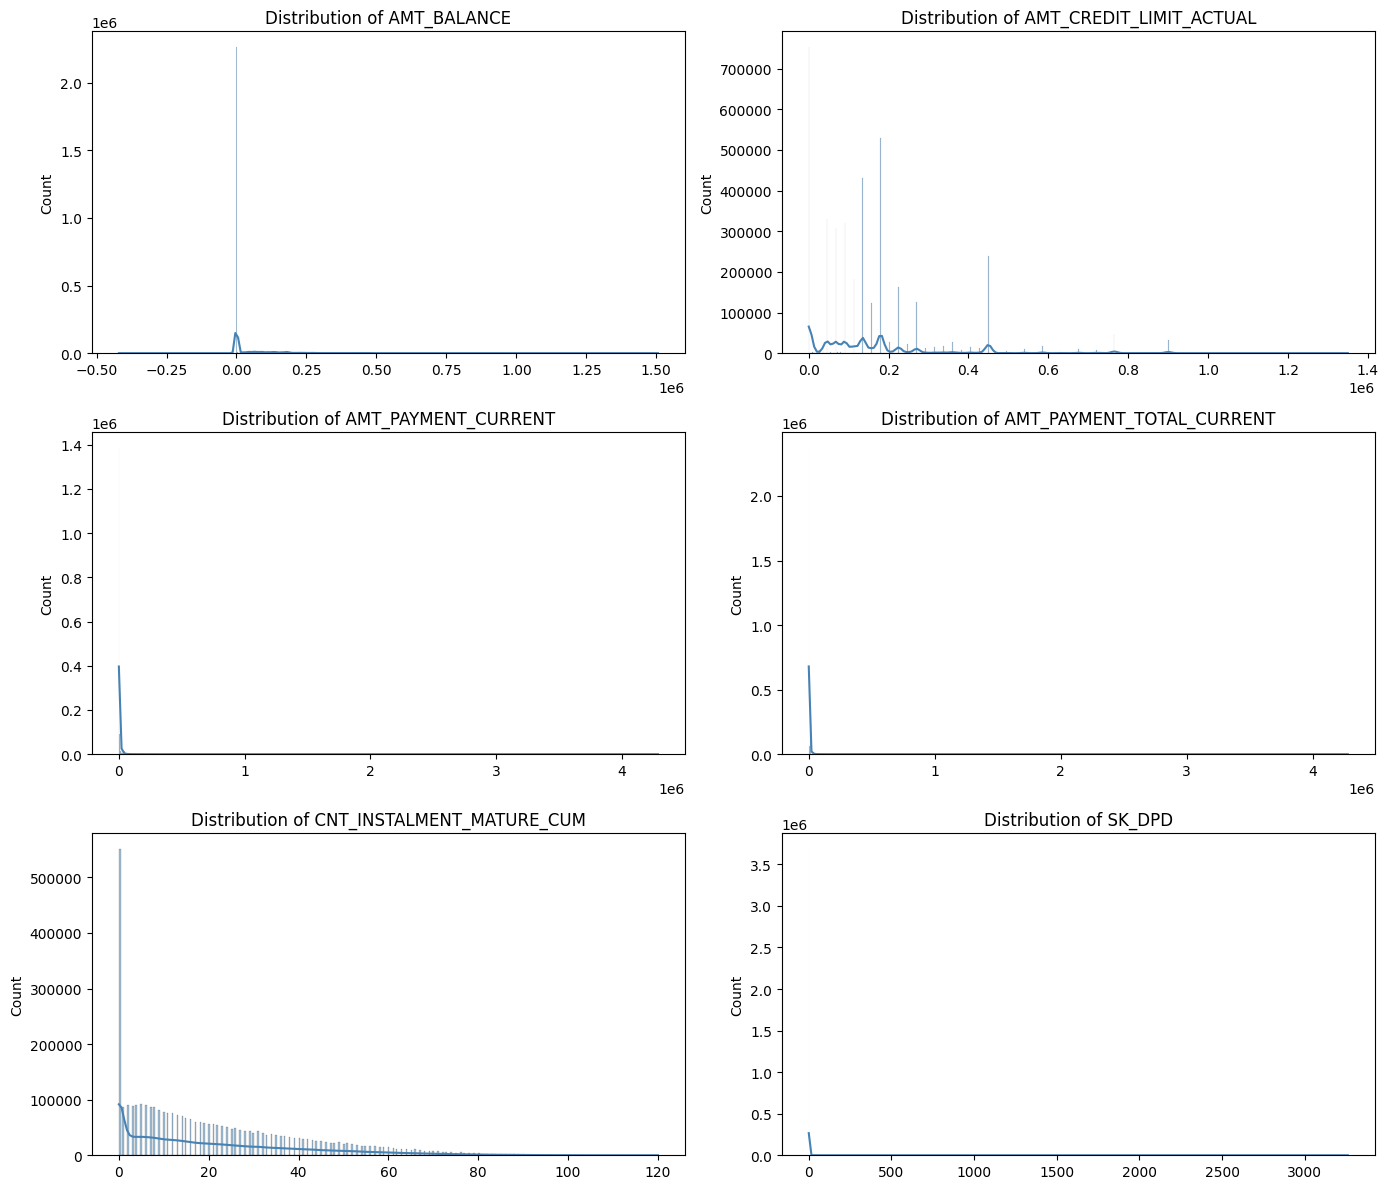

In [11]:
# Select key numerical features for distribution analysis
num_features_dist = [
    'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL',
    'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
    'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_features_dist):
    sns.histplot(df_cc[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

##### Key Findings

- `AMT_BALANCE` shows a spike at zero with a long right tail extending to 1.5M, and a visible left tail confirming negative balance values. The majority of months have zero or near-zero balance. **Negative values require investigation and handling.**
- `AMT_CREDIT_LIMIT_ACTUAL` shows a discrete distribution with distinct spikes at standard credit limit tiers (45k, 90k, 135k, 180k, 225k, 450k), reflecting structured credit limit assignment policy.
- `AMT_PAYMENT_CURRENT` and `AMT_PAYMENT_TOTAL_CURRENT` are both heavily compressed near zero with extreme right tails extending to 4.3M, confirming most months have zero or minimal payment activity.
- `CNT_INSTALMENT_MATURE_CUM` is right-skewed with a sharp spike at 0 followed by a gradual decline, reflecting varying credit card maturity stages across applicants.
- `SK_DPD` is almost entirely at zero with an extreme right tail extending to 3,260, consistent with POS_CASH_balance findings. **Capping recommended.**

---

### 4.1.3 Outlier Detection

Boxplots are used to detect outliers in numerical features. Extreme values can distort model training and may require capping or domain-aware treatment before modeling.

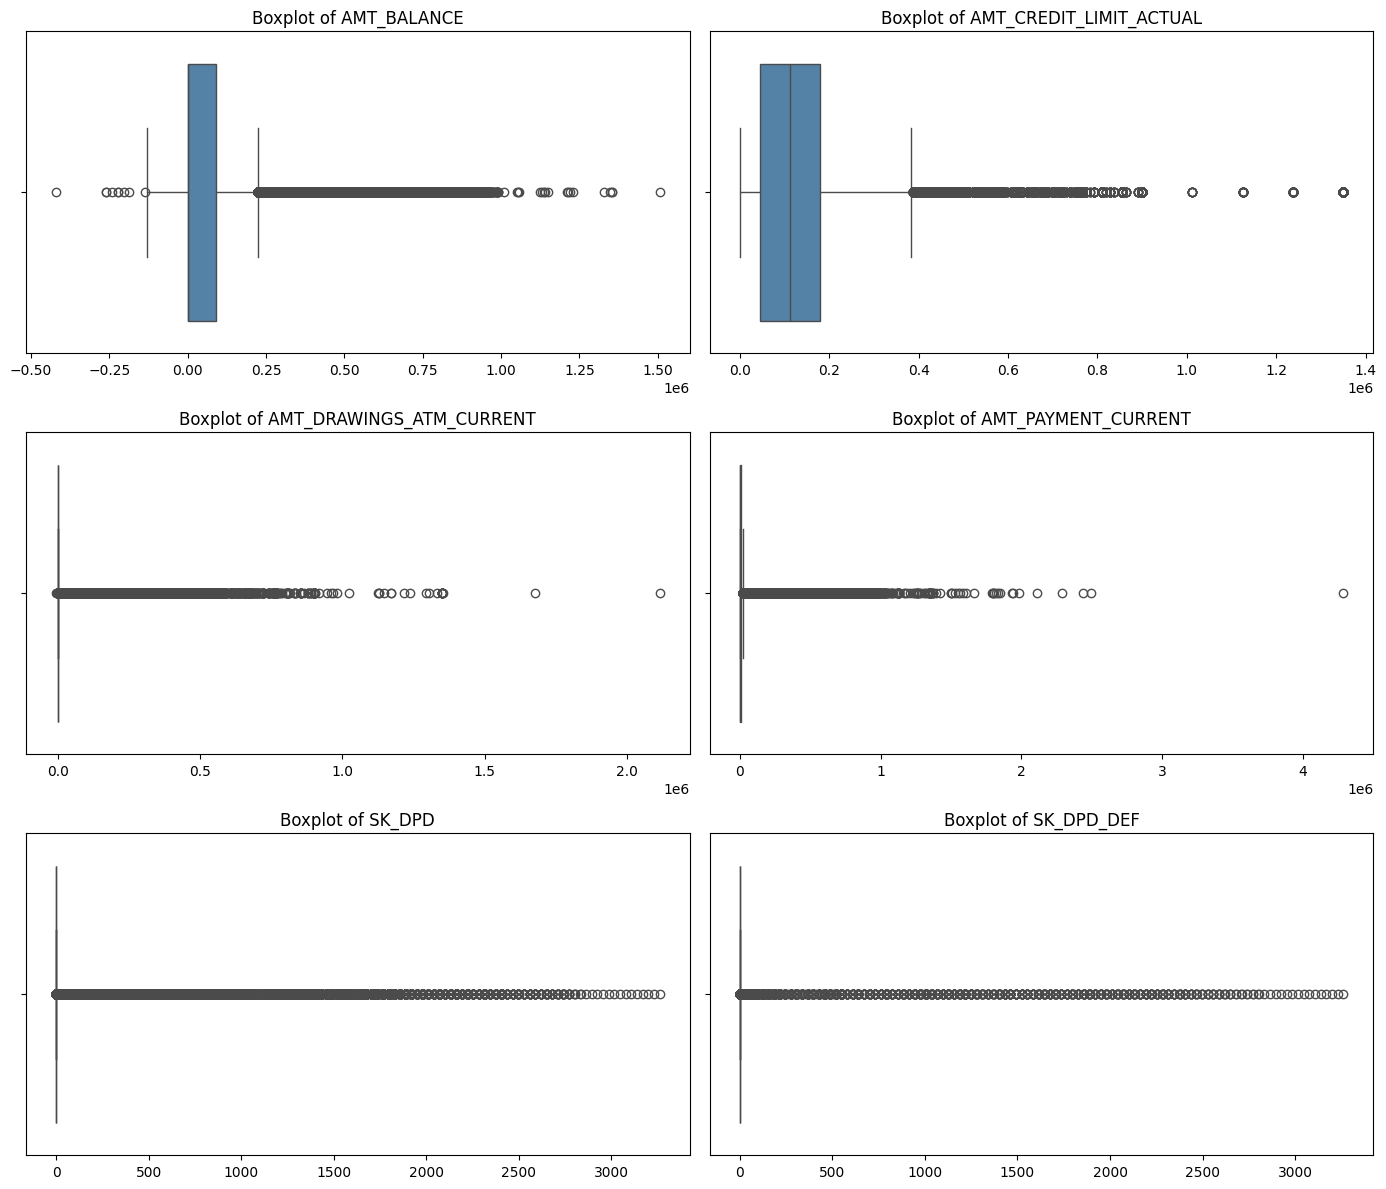

In [12]:
# Select key numerical features for outlier detection
outlier_features = [
    'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL',
    'AMT_DRAWINGS_ATM_CURRENT', 'AMT_PAYMENT_CURRENT',
    'SK_DPD', 'SK_DPD_DEF'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df_cc[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


##### Key Findings

- `AMT_BALANCE` shows negative outliers on the left (down to -420k) and extreme positive outliers on the right (up to 1.5M). **Negative values need investigation and clipping.**
- `AMT_CREDIT_LIMIT_ACTUAL` shows moderate outliers above 450k extending to 1.35M, **needs capping.**
- `AMT_DRAWINGS_ATM_CURRENT` shows extreme outliers up to 2.1M with the IQR entirely at zero, **needs capping.**
- `AMT_PAYMENT_CURRENT` shows extreme outliers up to 4.3M, **needs capping.**
- `SK_DPD` and `SK_DPD_DEF` both show extreme outliers up to 3,260 with IQR entirely at zero, consistent with POS_CASH_balance. **Needs capping.**

All amount features and DPD features require outlier treatment before aggregation. Negative balance values require domain-aware investigation before imputation.

---

## 4.2 Bivariate Between Features

This section examines pairwise correlations between numerical features in `credit_card_balance` to detect multicollinearity and identify redundant features before aggregation.

The approach includes:
- **Heatmap** to visualize pairwise correlation between numerical features

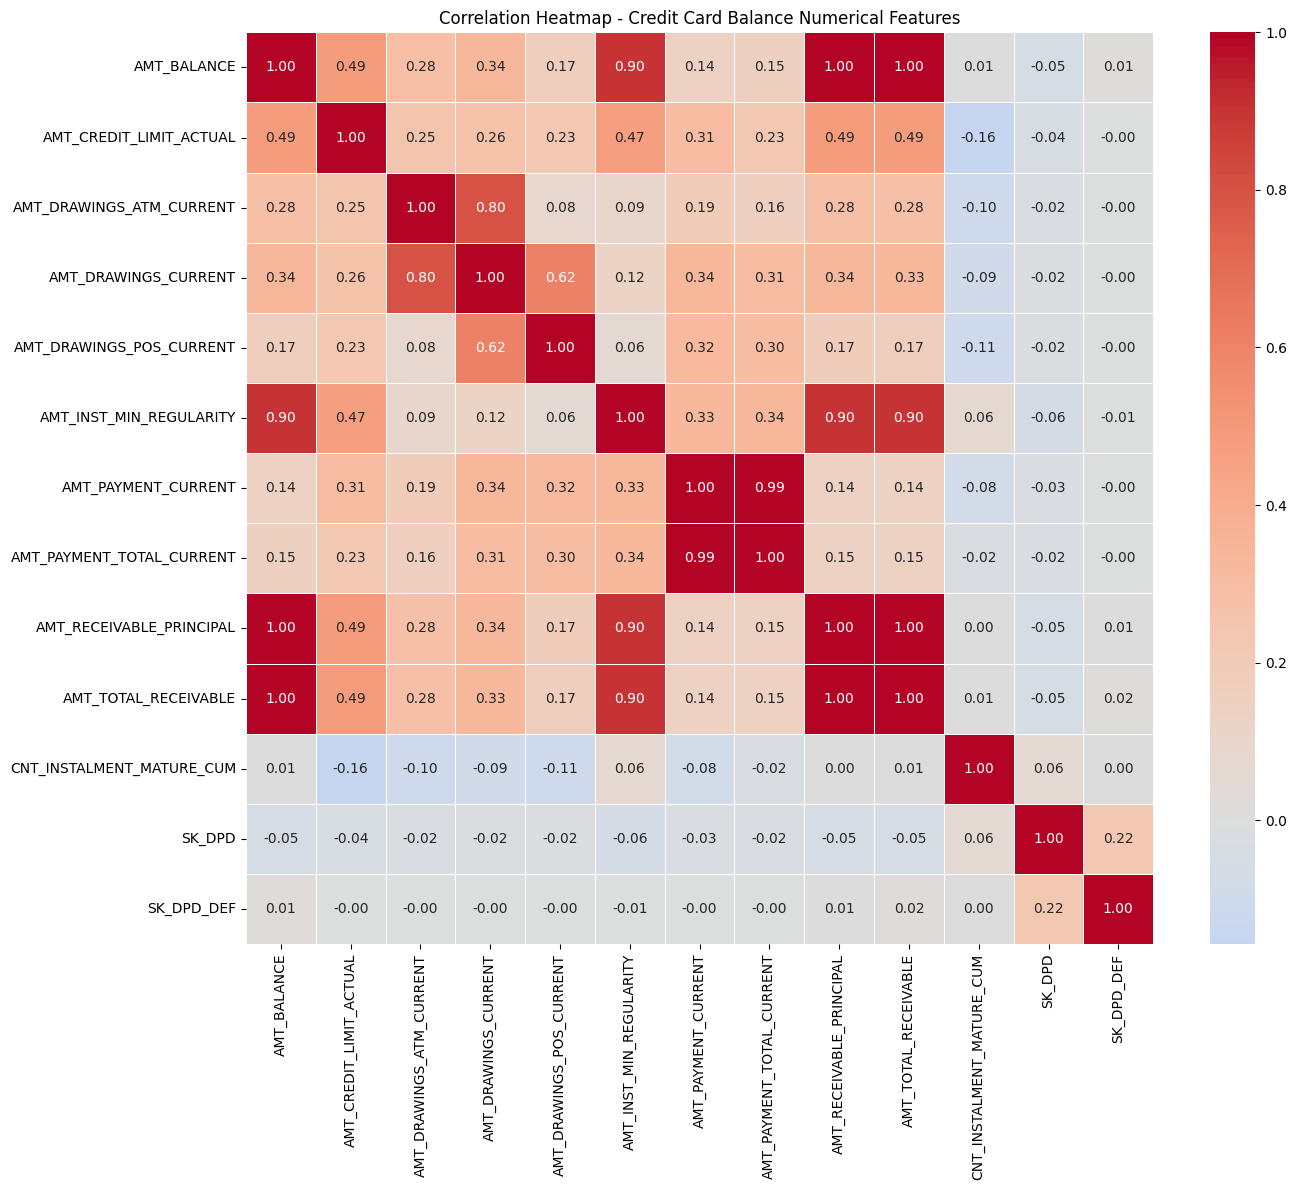

In [13]:
# Select relevant numerical features for correlation analysis
num_cols_corr = [
    'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL',
    'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT',
    'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
    'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
    'AMT_RECEIVABLE_PRINCIPAL', 'AMT_TOTAL_RECEIVABLE',
    'CNT_INSTALMENT_MATURE_CUM', 'SK_DPD', 'SK_DPD_DEF'
]

# Correlation heatmap - credit card balance numerical features
plt.figure(figsize=(14, 12))
corr_cc = df_cc[num_cols_corr].corr()
sns.heatmap(
    corr_cc,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap - Credit Card Balance Numerical Features')
plt.tight_layout()
plt.show()

#### Key Findings

**Perfect Multicollinearity: Balance Features**
`AMT_BALANCE`, `AMT_RECEIVABLE_PRINCIPAL`, and `AMT_TOTAL_RECEIVABLE` are perfectly correlated (1.00), confirming they capture identical information. Retain only `AMT_BALANCE` during feature selection and drop the other two to reduce redundancy.

**Very High Correlation: AMT_INST_MIN_REGULARITY with Balance Features**
`AMT_INST_MIN_REGULARITY` shows very high correlation with `AMT_BALANCE` (0.90), `AMT_RECEIVABLE_PRINCIPAL` (0.90), and `AMT_TOTAL_RECEIVABLE` (0.90), indicating minimum payment regularity is closely tied to outstanding balance. Consider dropping or deriving a ratio feature instead.

**High Correlation: Payment Features**
`AMT_PAYMENT_CURRENT` and `AMT_PAYMENT_TOTAL_CURRENT` are almost perfectly correlated (0.99), capturing near-identical payment information. Retain only one during feature selection.

**High Correlation: Drawing Features**
`AMT_DRAWINGS_ATM_CURRENT` and `AMT_DRAWINGS_CURRENT` show high correlation (0.80), and `AMT_DRAWINGS_CURRENT` with `AMT_DRAWINGS_POS_CURRENT` (0.62). Consider retaining only `AMT_DRAWINGS_CURRENT` as the aggregate drawing feature.

**Low Correlation: DPD Features vs Others**
`SK_DPD` and `SK_DPD_DEF` show near-zero correlation with all other features, confirming delinquency behavior is independent of balance and drawing activity. Both are moderately correlated with each other (0.22).

**CNT_INSTALMENT_MATURE_CUM is Independent**
Near-zero correlation with all amount features, confirming it captures a completely independent dimension of credit card maturity. Retain as a standalone feature.

**Features to Watch During Aggregation**
- `AMT_BALANCE`, `AMT_RECEIVABLE_PRINCIPAL`, `AMT_TOTAL_RECEIVABLE`: retain only `AMT_BALANCE`
- `AMT_PAYMENT_CURRENT`, `AMT_PAYMENT_TOTAL_CURRENT`: retain only one
- `AMT_DRAWINGS_ATM_CURRENT`, `AMT_DRAWINGS_CURRENT`, `AMT_DRAWINGS_POS_CURRENT`: retain only `AMT_DRAWINGS_CURRENT` or derive total drawing feature

---

# 5. Categorical Features Analysis

`credit_card_balance` contains only one categorical feature (`NAME_CONTRACT_STATUS`). This section examines its distribution and relationship with `TARGET`.

In [14]:
# Value counts and percentage
print(df_cc['NAME_CONTRACT_STATUS'].value_counts())
print(f"\nDistribution (%):")
print((df_cc['NAME_CONTRACT_STATUS'].value_counts() / len(df_cc) * 100).round(2))

NAME_CONTRACT_STATUS
Active           3698436
Completed         128918
Signed             11058
Demand              1365
Sent proposal        513
Refused               17
Approved               5
Name: count, dtype: int64

Distribution (%):
NAME_CONTRACT_STATUS
Active           96.31
Completed         3.36
Signed            0.29
Demand            0.04
Sent proposal     0.01
Refused           0.00
Approved          0.00
Name: count, dtype: float64


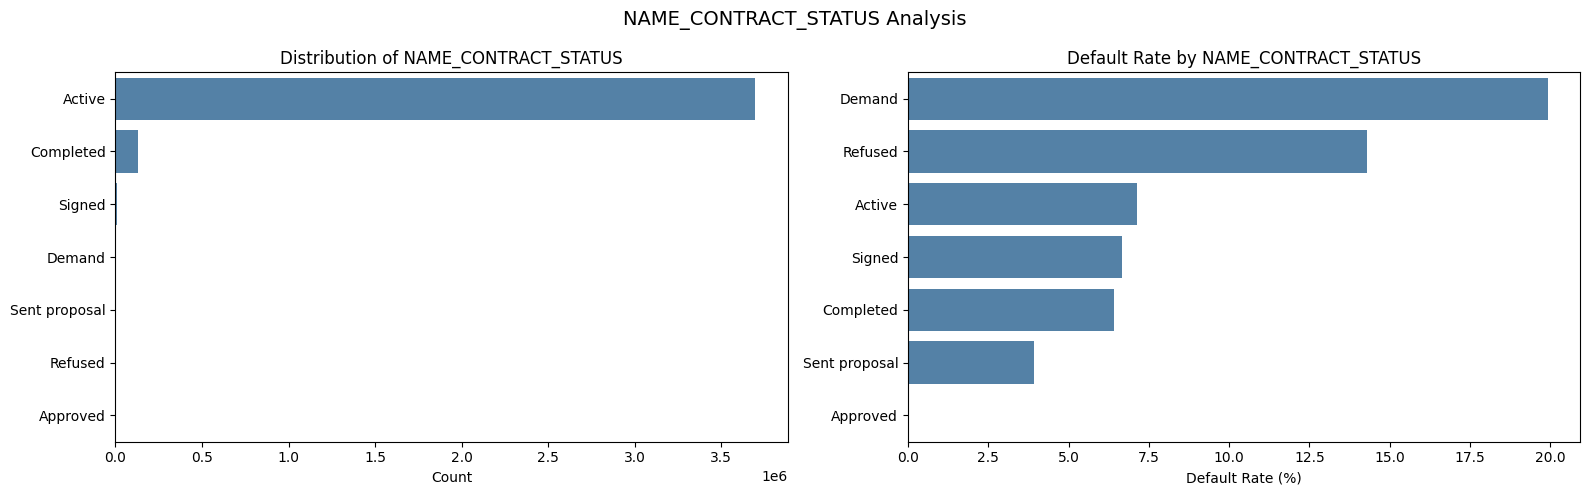

In [15]:
# Frequency plot and default rate side by side
df_cc_target = df_cc.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Frequency plot
order = df_cc['NAME_CONTRACT_STATUS'].value_counts().index
sns.countplot(data=df_cc, y='NAME_CONTRACT_STATUS', order=order, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of NAME_CONTRACT_STATUS')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

# Default rate plot
default_rate_cc = df_cc_target.groupby('NAME_CONTRACT_STATUS')['TARGET'].mean() * 100
default_rate_cc = default_rate_cc.sort_values(ascending=False)
sns.barplot(x=default_rate_cc.values, y=default_rate_cc.index, ax=axes[1], color='steelblue')
axes[1].set_title('Default Rate by NAME_CONTRACT_STATUS')
axes[1].set_xlabel('Default Rate (%)')
axes[1].set_ylabel('')

plt.suptitle('NAME_CONTRACT_STATUS Analysis', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Findings

**Active Dominates**
`Active` accounts for 96.31% of all monthly records, significantly higher than POS_CASH_balance (91.50%), reflecting that credit cards tend to remain open longer than POS/cash loans. `Completed` accounts for only 3.36%, confirming most credit cards are still active at the time of application.

**Demand is the Highest Risk Status**
`Demand` shows the highest default rate (~20%), consistent with findings in POS_CASH_balance. Despite only 1,365 records, this status is a strong binary risk signal worth preserving during aggregation.

**Refused Shows Elevated Risk**
`Refused` (~14%) shows notably higher default rate than `Active` (~7%), suggesting applicants whose credit cards were refused carry elevated current default risk. However with only 17 records, this should be treated carefully during aggregation.

**Approved and Sent Proposal Show Low Risk**
`Approved` and `Sent proposal` show low default rates (~0% and ~4% respectively), likely reflecting early-stage credit card applications before any delinquency could occur.

---

# Aggregation

This section aggregates `credit_card_balance` into applicant-level features ready for merging into the main modeling table. Aggregation is performed in a single step directly to `SK_ID_CURR` level.

The approach includes:
- **Aggregating** `credit_card_balance` to `SK_ID_CURR` level to derive applicant-level credit card behavior features

## Credit Card Balance to SK_ID_CURR

Monthly credit card balance records are aggregated to applicant level using `SK_ID_CURR` as the key. This produces one row per applicant containing summarized credit card usage and payment behavior features ready for merging into `application_train`.

In [17]:
# Aggregate credit_card_balance to SK_ID_CURR level
df_cc_agg = df_cc.groupby('SK_ID_CURR').agg(
    # Record count
    CC_COUNT=('SK_ID_PREV', 'count'),
    CC_UNIQUE_CARDS=('SK_ID_PREV', 'nunique'),

    # Balance features
    CC_AMT_BALANCE_MEAN=('AMT_BALANCE', 'mean'),
    CC_AMT_BALANCE_MAX=('AMT_BALANCE', 'max'),
    CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    CC_AMT_CREDIT_LIMIT_ACTUAL_MAX=('AMT_CREDIT_LIMIT_ACTUAL', 'max'),

    # Payment features
    CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN=('AMT_PAYMENT_TOTAL_CURRENT', 'mean'),
    CC_AMT_PAYMENT_TOTAL_CURRENT_SUM=('AMT_PAYMENT_TOTAL_CURRENT', 'sum'),
    CC_AMT_INST_MIN_REGULARITY_MEAN=('AMT_INST_MIN_REGULARITY', 'mean'),

    # Drawing features
    CC_AMT_DRAWINGS_CURRENT_MEAN=('AMT_DRAWINGS_CURRENT', 'mean'),
    CC_AMT_DRAWINGS_CURRENT_SUM=('AMT_DRAWINGS_CURRENT', 'sum'),
    CC_AMT_DRAWINGS_ATM_CURRENT_MEAN=('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
    CC_CNT_DRAWINGS_CURRENT_MEAN=('CNT_DRAWINGS_CURRENT', 'mean'),

    # Instalment maturity
    CC_CNT_INSTALMENT_MATURE_CUM_MEAN=('CNT_INSTALMENT_MATURE_CUM', 'mean'),
    CC_CNT_INSTALMENT_MATURE_CUM_MAX=('CNT_INSTALMENT_MATURE_CUM', 'max'),

    # DPD features
    CC_SK_DPD_MEAN=('SK_DPD', 'mean'),
    CC_SK_DPD_MAX=('SK_DPD', 'max'),
    CC_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    CC_SK_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),

    # Contract status counts
    CC_ACTIVE_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),
    CC_COMPLETED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    CC_DEMAND_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Demand').sum()),
).reset_index()

In [18]:
# Proportion features
# cc_prop_active = CC_ACTIVE_COUNT / CC_COUNT
df_cc_agg['CC_PROP_ACTIVE'] = (df_cc_agg['CC_ACTIVE_COUNT'] / df_cc_agg['CC_COUNT']).round(4)
df_cc_agg['CC_PROP_COMPLETED'] = (df_cc_agg['CC_COMPLETED_COUNT'] / df_cc_agg['CC_COUNT']).round(4)

# Binary flag features
df_cc_agg['CC_HAS_DEMAND'] = (df_cc_agg['CC_DEMAND_COUNT'] >= 1).astype(int)

# Credit utilization ratio
df_cc_agg['CC_UTILIZATION_RATIO'] = (
    df_cc_agg['CC_AMT_BALANCE_MEAN'] / df_cc_agg['CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN']
).round(4)

print("Shape df_cc_agg:", df_cc_agg.shape)
df_cc_agg.head()

Shape df_cc_agg: (103558, 27)


,SK_ID_CURR,CC_COUNT,CC_UNIQUE_CARDS,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_INST_MIN_REGULARITY_MEAN,...,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MEAN,CC_SK_DPD_DEF_MAX,CC_ACTIVE_COUNT,CC_COMPLETED_COUNT,CC_DEMAND_COUNT,CC_PROP_ACTIVE,CC_PROP_COMPLETED,CC_HAS_DEMAND,CC_UTILIZATION_RATIO
0,100006,6,1,0.000000,0.00,270000.000000,270000,0.000000,0.000,0.000000,...,0,0.000000,0,6,0,0,1.0000,0.0000,0,0.0000
1,100011,74,1,54482.111149,189000.00,164189.189189,180000,4520.067568,334485.000,3956.221849,...,0,0.000000,0,74,0,0,1.0000,0.0000,0,0.3318
2,100013,96,1,18159.919219,161420.22,131718.750000,157500,6817.172344,654448.545,1454.539551,...,1,0.010417,1,96,0,0,1.0000,0.0000,0,0.1379
3,100021,17,1,0.000000,0.00,675000.000000,675000,0.000000,0.000,0.000000,...,0,0.000000,0,7,10,0,0.4118,0.5882,0,0.0000
4,100023,8,1,0.000000,0.00,135000.000000,225000,0.000000,0.000,0.000000,...,0,0.000000,0,8,0,0,1.0000,0.0000,0,0.0000


In [19]:
# Merge credit_card_balance aggregations with application_train
df_cc_agg_target = df_cc_agg.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

print("Shape df_cc_agg_target:", df_cc_agg_target.shape)

Shape df_cc_agg_target: (103558, 28)


# 6. Bivariate Aggregated Features vs TARGET

This section examines the relationship between aggregated credit card balance features and the target variable (`TARGET`). The goal is to identify which aggregated features carry the strongest signal for predicting loan default.

The approach includes:
- **KDE plots** to compare distributions of aggregated numerical features between default and non-default applicants
- **Default rate plots** to evaluate default rate per category for aggregated categorical features

## 6.1 Numerical Aggregated Features

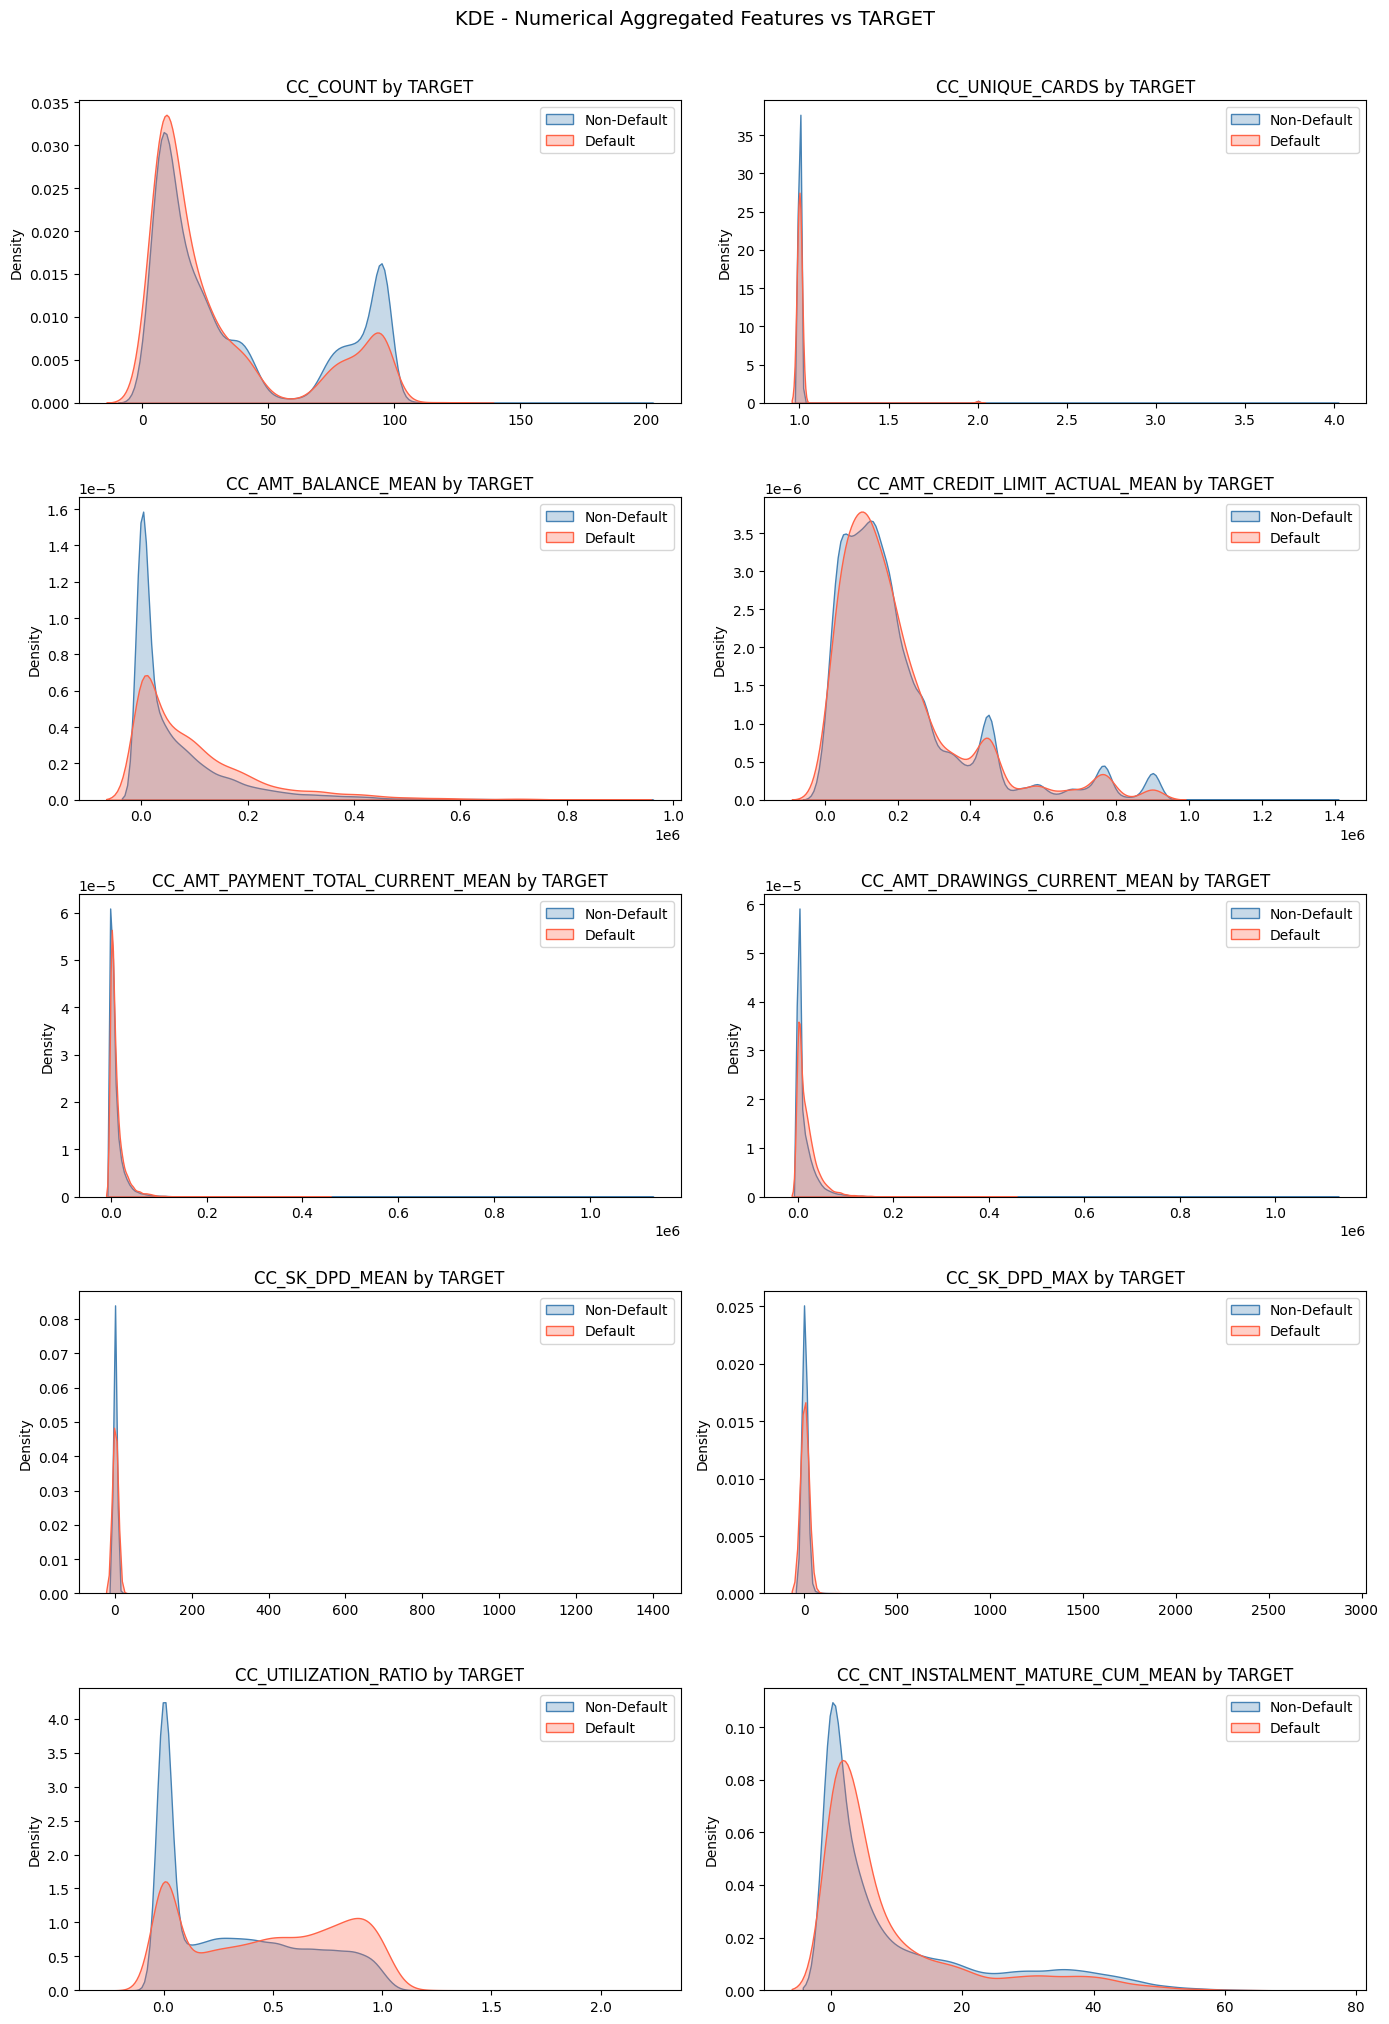

In [20]:
# Select key numerical aggregated features for bivariate analysis
num_agg_features = [
    'CC_COUNT',
    'CC_UNIQUE_CARDS',
    'CC_AMT_BALANCE_MEAN',
    'CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN',
    'CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN',
    'CC_AMT_DRAWINGS_CURRENT_MEAN',
    'CC_SK_DPD_MEAN',
    'CC_SK_DPD_MAX',
    'CC_UTILIZATION_RATIO',
    'CC_CNT_INSTALMENT_MATURE_CUM_MEAN',
]

# Grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_agg_features):
    for target_val, label, color in zip([0, 1], ['Non-Default', 'Default'], ['steelblue', 'tomato']):
        subset = df_cc_agg_target[df_cc_agg_target['TARGET'] == target_val][col].dropna()
        sns.kdeplot(subset, ax=axes[i], label=label, color=color, fill=True, alpha=0.3)
    axes[i].set_title(f'{col} by TARGET')
    axes[i].set_xlabel('')
    axes[i].legend()

plt.suptitle('KDE - Numerical Aggregated Features vs TARGET', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Key Findings - Numerical Aggregated Features

**CC_COUNT**
Default applicants show higher density at lower monthly record counts, while non-default applicants spread toward higher counts with a notable peak around 96 months. Longer credit card history is associated with lower default risk.

**CC_UNIQUE_CARDS**
Both classes are heavily concentrated at 1 unique card, with default applicants showing slightly higher density. Applicants with 2 unique cards show notably higher default rates based on categorical analysis below.

**CC_AMT_BALANCE_MEAN**
Default applicants show higher density near zero while non-default applicants spread slightly more toward higher balances. Limited visual separation due to extreme right skew.

**CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN**
Non-default applicants show higher credit limits at standard tiers (180k, 450k, 900k), while default applicants are concentrated at lower limits. Higher credit limits are associated with lower default risk, reflecting better creditworthiness assessment.

**CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN and CC_AMT_DRAWINGS_CURRENT_MEAN**
Both distributions are heavily compressed near zero with extreme right tails. Limited discriminative power in raw form due to skewness.

**CC_SK_DPD_MEAN and CC_SK_DPD_MAX**
Default applicants show heavier tails toward higher DPD values compared to non-default. While most values are near zero for both classes, non-zero DPD values are more prevalent among default applicants, confirming DPD as a meaningful signal.

**CC_UTILIZATION_RATIO**
Clear separation between classes. Non-default applicants show a strong peak near 0 (low utilization), while default applicants show a flatter distribution extending toward higher utilization ratios. Higher credit utilization is associated with higher default risk, making this one of the most discriminative derived features.

**CC_CNT_INSTALMENT_MATURE_CUM_MEAN**
Non-default applicants show higher average cumulative mature installments, suggesting longer credit card tenure is associated with lower default risk.

---

## 6.2 Categorical Aggregated Features

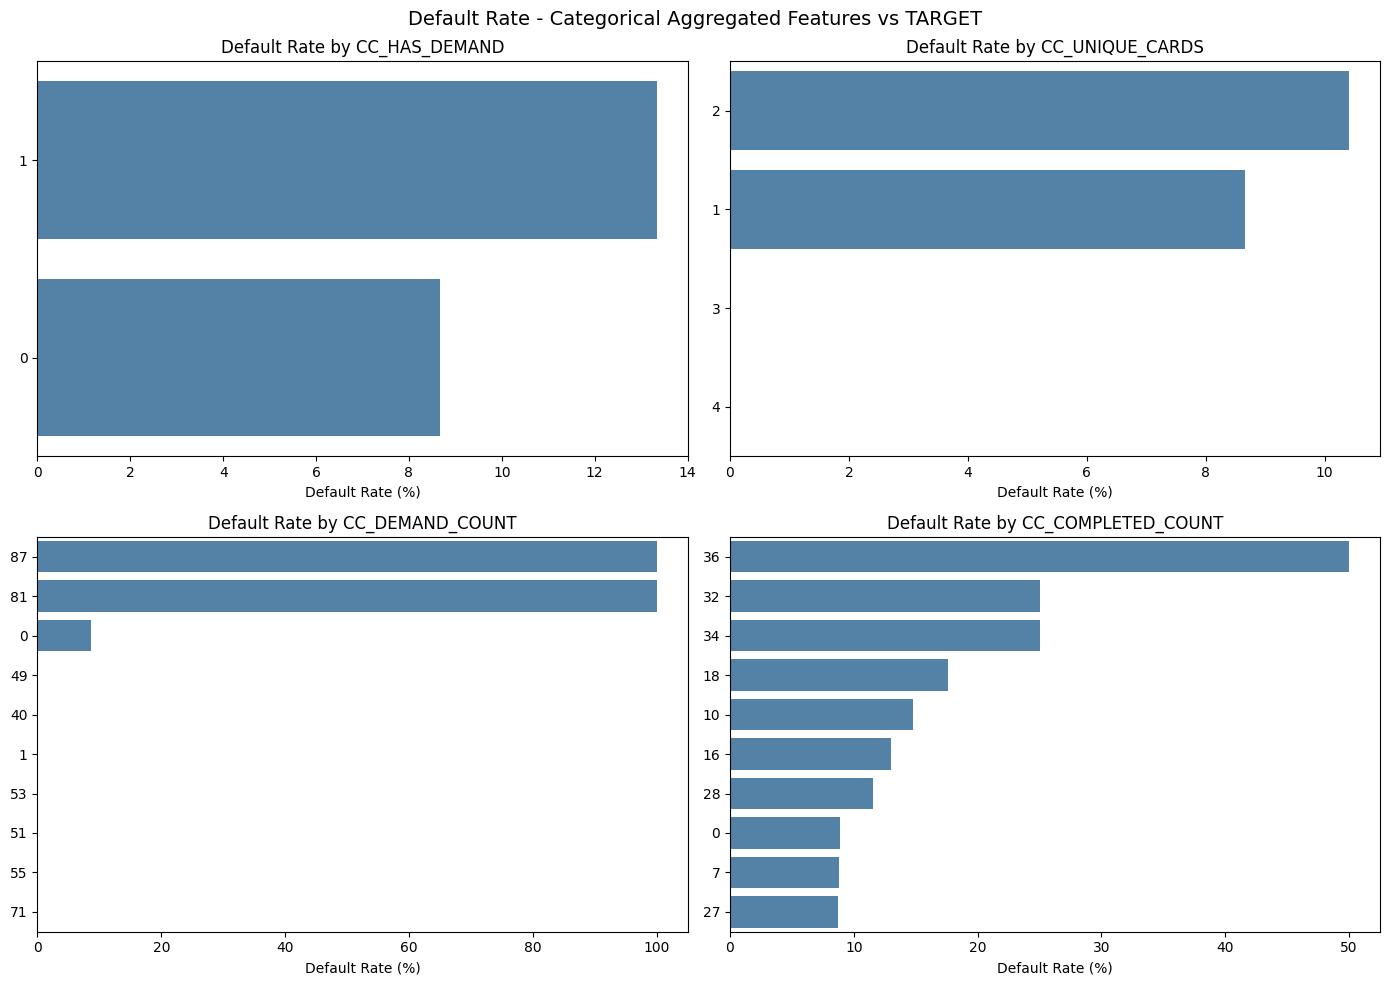

In [21]:
# Select categorical aggregated features for default rate analysis
cat_agg_features = [
    'CC_HAS_DEMAND',
    'CC_UNIQUE_CARDS',
    'CC_DEMAND_COUNT',
    'CC_COMPLETED_COUNT',
]

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_agg_features):
    default_rate = df_cc_agg_target.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False).head(10)
    sns.barplot(x=default_rate.values, y=default_rate.index.astype(str),
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

plt.suptitle('Default Rate - Categorical Aggregated Features vs TARGET', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Findings - Categorical Aggregated Features

**CC_HAS_DEMAND**
Applicants with at least one demand month show default rate of ~14% compared to ~8% for those without, confirming demand status as a meaningful binary risk signal consistent with POS_CASH_balance findings.

**CC_UNIQUE_CARDS**
Applicants with 2 unique cards show the highest default rate (~10%), while those with 3-4 cards show near-zero rates. Non-linear relationship suggests moderate card diversity may carry different risk profiles than single or multiple card holders.

**CC_DEMAND_COUNT**
Extreme default rates approaching 100% at high demand counts (81, 87), confirming that repeated demand status months are among the strongest risk signals in this dataset.

**CC_COMPLETED_COUNT**
Non-linear relationship where very high completed counts (36) show extremely high default rates (~50%), while moderate counts show lower rates. Similar pattern to bureau closed count, suggesting aggressive historical credit card usage may be a risk indicator.

---

# 7. Insights & Recommendations

## 7.1 Key Findings

**Credit Card Coverage is Limited**
Only 103,558 unique applicants have credit card balance records, covering approximately 34% of `application_train` applicants. This is significantly lower than bureau (85.69%), previous_application (110%), and POS_CASH_balance (109%), indicating that credit card history is available for a minority of applicants. After merging, the majority of applicants will have NaN for all `CC_*` features.

**Credit Utilization is the Most Discriminative Derived Feature**
`CC_UTILIZATION_RATIO` shows the clearest class separation among all aggregated features, with non-default applicants concentrated near 0 and default applicants spread across higher utilization values. This confirms that credit utilization is a strong behavioral signal for default prediction.

**Demand Status Confirms Financial Distress**
`CC_HAS_DEMAND` and `CC_DEMAND_COUNT` show strong monotonic relationships with default rate, reaching 100% at high demand counts. Consistent with findings in POS_CASH_balance, demand status is one of the strongest binary risk signals across all Home Credit datasets.

**DPD Features Require Treatment but Carry Signal**
`CC_SK_DPD_MEAN` and `CC_SK_DPD_MAX` show extreme outliers and compression near zero, but default applicants show heavier tails toward higher values. Capping at 99th percentile is recommended before use in modeling.

**High Multicollinearity Among Raw Features**
`AMT_BALANCE`, `AMT_RECEIVABLE_PRINCIPAL`, and `AMT_TOTAL_RECEIVABLE` are perfectly correlated (1.00), and `AMT_PAYMENT_CURRENT` and `AMT_PAYMENT_TOTAL_CURRENT` are near-perfectly correlated (0.99). Retaining only one from each group is recommended during feature selection.

**Credit Limit as Proxy for Creditworthiness**
`CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN` shows visible class separation, with non-default applicants having higher credit limits. Credit limit reflects historical creditworthiness assessment and carries meaningful predictive signal.

---


## 7.2 Recommended Aggregated Features

**Balance and Limit Features:**
- `CC_AMT_BALANCE_MEAN`, `CC_AMT_BALANCE_MAX`: outstanding balance behavior
- `CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN`, `CC_AMT_CREDIT_LIMIT_ACTUAL_MAX`: credit limit profile

**Payment Features:**
- `CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN`: average monthly payment behavior
- `CC_AMT_INST_MIN_REGULARITY_MEAN`: minimum payment regularity

**Drawing Features:**
- `CC_AMT_DRAWINGS_CURRENT_MEAN`: average monthly drawing activity
- `CC_CNT_DRAWINGS_CURRENT_MEAN`: average drawing frequency

**DPD Features:**
- `CC_SK_DPD_MEAN`, `CC_SK_DPD_MAX`: average and worst days past due
- `CC_SK_DPD_DEF_MEAN`, `CC_SK_DPD_DEF_MAX`: defined DPD variants

**Count and Flag Features:**
- `CC_COUNT`: total monthly records per applicant
- `CC_UNIQUE_CARDS`: number of distinct credit cards
- `CC_DEMAND_COUNT`: count of demand status months
- `CC_HAS_DEMAND`: binary flag for ever having demand status

**Derived Features Recommended:**
- `CC_UTILIZATION_RATIO`: mean balance to mean credit limit ratio, strongest discriminative feature
- `CC_CNT_INSTALMENT_MATURE_CUM_MEAN`: average credit card tenure

---

## 7.3 Handling Strategy

**Missing Values after Merge:**
- Approximately 66% of applicants in `application_train` have no credit card balance records. Impute all `CC_*` features with **0** after merging, as absence of credit card history is a meaningful signal in itself.
- `CC_UTILIZATION_RATIO`: handle division by zero cases where `CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN` = 0 by imputing with **0**.

**Outlier Treatment:**
- `CC_SK_DPD_MAX`, `CC_SK_DPD_MEAN`: cap at 99th percentile
- `CC_SK_DPD_DEF_MAX`, `CC_SK_DPD_DEF_MEAN`: cap at 99th percentile
- `CC_AMT_BALANCE_MEAN`, `CC_AMT_DRAWINGS_CURRENT_MEAN`: cap at 99th percentile
- Negative balance values: investigate and clip to 0 before aggregation

**Redundant Features to Drop:**
- `AMT_RECEIVABLE_PRINCIPAL`, `AMT_TOTAL_RECEIVABLE`: perfectly correlated with `AMT_BALANCE`
- `AMT_PAYMENT_CURRENT`: near-perfectly correlated with `AMT_PAYMENT_TOTAL_CURRENT`
- `AMT_DRAWINGS_ATM_CURRENT`: highly correlated with `AMT_DRAWINGS_CURRENT`

**All transformations and imputations to be implemented in `Data Cleaning and Handling.ipynb`.**

---

In [22]:
# Read markdown cells from notebook
import json

with open('EDA_credit_card_balance.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'markdown':
        print(f"--- Cell {i} ---")
        print(''.join(cell['source']))
        print()

--- Cell 0 ---
# Exploratory Data Analysis (EDA)
## Dataset: credit_card_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `credit_card_balance` dataset from the Home Credit risk modeling case. This table contains monthly balance snapshots of previous credit cards held by applicants at Home Credit, providing behavioral signals on credit card usage and payment patterns for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `credit_card_balance` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main 